# 01 — Análisis Exploratorio de Datos (EDA) e Ingesta

## 1. Contextualización del Problema y Datos
El presente estudio busca analizar la relación entre las **variables ambientales y de contaminación atmosférica** de la ciudad de Bogotá y la **biodiversidad de aves urbanas**, medida a través del **Índice de Diversidad de Shannon ($H'$)** derivado de registros de ciencia ciudadana (*eBird*).

Los datos ambientales provienen de la Red de Monitoreo de Calidad del Aire de Bogotá (RMCAB) y de IDEAM. Contemplan variables continuas como material particulado ($PM_{2.5}$, $PM_{10}$), gases contaminantes ($NO_2$, $CO$, $O_3$), y variables meteorológicas (Temperatura, Humedad, Viento, Radiación Solar), así como la ocurrencia de Lluvia (variable bimodal). Las observaciones de aves eBird se cruzaron espacio-temporalmente con la estación de monitoreo más cercana dentro de un radio máximo de 5.5 km y una ventana temporal estricta de ±1 hora.

En esta sección realizamos un Análisis Exploratorio de Datos (EDA) para evaluar las distribuciones originales, identificar la presencia de asimetrías severas, examinar correlaciones lineales y no lineales (LOWESS), y contrastar descriptivamente las condiciones ambientales asociadas a la baja (Q1) y alta (Q3) diversidad.

In [1]:
from pathlib import Path
import os
from types import SimpleNamespace
import IPython.display as display

ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
os.chdir(ROOT)

# Funciones incorporadas localmente para que el notebook sea aut?nomo.
from pathlib import Path

import matplotlib
matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats


DATA_PATH = Path("Data/Processed/analysis_env_complete.parquet")
OUTPUT_DIR = Path("Outputs")
FIG_DIR = Path("Figures/EDA")

RESPONSE = "Shannon_Index"
ENV_VARS = [
    "PM2.5",
    "PM10",
    "NO2",
    "CO",
    "O3",
    "Temperatura",
    "Humedad",
    "Viento",
    "Lluvia",
    "Radiacion_Solar",
]
CONTINUOUS_ENV_VARS = [col for col in ENV_VARS if col != "Lluvia"]
CORRELATION_ENV_VARS = CONTINUOUS_ENV_VARS
RAW_AUX_VARS = ["Precipitacion"]
ECO_VARS = [RESPONSE, "Riqueza_Especies"]
SPATIAL_VARS = ["Distance_to_Station_km"]
Z_ENV_VARS = [f"z_env_{col}" for col in ENV_VARS]
Z_CONTINUOUS_ENV_VARS = [f"z_env_{col}" for col in CONTINUOUS_ENV_VARS]


def safe_name(name):
    return (
        name.replace(".", "_")
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
    )


def save_descriptives(df):
    cols = ECO_VARS + SPATIAL_VARS + ENV_VARS + RAW_AUX_VARS
    desc = df[cols].describe(percentiles=[0.25, 0.5, 0.75]).T
    desc["missing_n"] = df[cols].isna().sum()
    desc["missing_pct"] = (df[cols].isna().mean() * 100).round(2)
    desc["skew"] = df[cols].skew()
    desc["kurtosis"] = df[cols].kurtosis()
    desc.to_csv(OUTPUT_DIR / "eda_descriptive_env_complete.csv", encoding="utf-8")

    grouped = (
        df[df["Diversidad_Grupo"].isin(["Baja_Q1", "Alta_Q3"])]
        .groupby("Diversidad_Grupo")[cols]
        .agg(["count", "mean", "median", "std"])
    )
    grouped.to_csv(OUTPUT_DIR / "eda_q1_q3_group_summary.csv", encoding="utf-8")

    return desc, grouped


def save_correlations(df):
    corr_cols = ECO_VARS + SPATIAL_VARS + CORRELATION_ENV_VARS
    pearson = df[corr_cols].corr(method="pearson")
    spearman = df[corr_cols].corr(method="spearman")
    pearson.to_csv(OUTPUT_DIR / "eda_corr_pearson.csv", encoding="utf-8")
    spearman.to_csv(OUTPUT_DIR / "eda_corr_spearman.csv", encoding="utf-8")
    return pearson, spearman


def plot_shannon_distribution(df):
    q1 = df[RESPONSE].quantile(0.25)
    q3 = df[RESPONSE].quantile(0.75)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df[RESPONSE], bins=40, kde=True, ax=ax, color="#376996")
    ax.axvline(q1, color="#c84630", linestyle="--", linewidth=1.8, label=f"Q1 = {q1:.2f}")
    ax.axvline(q3, color="#2a9d8f", linestyle="--", linewidth=1.8, label=f"Q3 = {q3:.2f}")
    ax.set_title("Distribución del índice de Shannon")
    ax.set_xlabel("Shannon_Index")
    ax.set_ylabel("Frecuencia")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "01_shannon_distribution.png", dpi=180)
    plt.close(fig)


def plot_environment_distributions(df):
    fig, axes = plt.subplots(5, 2, figsize=(12, 16))
    axes = axes.ravel()
    for ax, col in zip(axes, ENV_VARS):
        if col == "Lluvia":
            counts = (
                df[col]
                .map({0: "Sin lluvia", 1: "Con lluvia"})
                .value_counts()
                .reindex(["Sin lluvia", "Con lluvia"], fill_value=0)
            )
            sns.barplot(x=counts.index, y=counts.values, ax=ax, color="#5f7f52")
            ax.set_ylim(0, counts.max() * 1.12)
            ax.bar_label(ax.containers[0], fmt="%.0f", fontsize=9)
        else:
            sns.histplot(df[col], bins=35, kde=True, ax=ax, color="#5f7f52")
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")
    fig.suptitle("Distribuciones de variables ambientales en escala original", y=1.0, fontsize=14)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "02_environment_distributions_original.png", dpi=180)
    plt.close(fig)


def plot_correlation_heatmap(corr):
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        corr,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"label": "Correlación de Pearson"},
        ax=ax,
    )
    ax.set_title("Matriz de correlación de Pearson")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "03_pearson_correlation_heatmap.png", dpi=180)
    plt.close(fig)


def plot_shannon_scatter_grid(df):
    key_vars = ["PM2.5", "PM10", "NO2", "O3", "Temperatura", "Humedad", "Viento", "Radiacion_Solar"]
    sample = df.sample(min(len(df), 3500), random_state=42)

    fig, axes = plt.subplots(4, 2, figsize=(12, 15))
    axes = axes.ravel()
    for ax, col in zip(axes, key_vars):
        sns.regplot(
            data=sample,
            x=col,
            y=RESPONSE,
            lowess=True,
            scatter_kws={"s": 8, "alpha": 0.25, "color": "#3f5364"},
            line_kws={"color": "#c84630", "linewidth": 1.6},
            ax=ax,
        )
        rho, p_value = stats.spearmanr(df[col], df[RESPONSE], nan_policy="omit")
        ax.set_title(f"{col} vs Shannon (Spearman rho={rho:.2f})")
        ax.set_xlabel(col)
        ax.set_ylabel("Shannon_Index")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "04_shannon_vs_environment_scatter.png", dpi=180)
    plt.close(fig)


def plot_q1_q3_boxplots(df):
    groups = df[df["Diversidad_Grupo"].isin(["Baja_Q1", "Alta_Q3"])].copy()
    long = groups.melt(
        id_vars="Diversidad_Grupo",
        value_vars=Z_CONTINUOUS_ENV_VARS,
        var_name="Variable",
        value_name="Z",
    )
    long["Variable"] = long["Variable"].str.replace("z_env_", "", regex=False)

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.boxplot(
        data=long,
        x="Variable",
        y="Z",
        hue="Diversidad_Grupo",
        palette={"Baja_Q1": "#c84630", "Alta_Q3": "#2a9d8f"},
        showfliers=False,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
    ax.set_xlabel("")
    ax.set_ylabel("Z-score")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "05_q1_q3_environment_boxplots_z.png", dpi=180)
    plt.close(fig)


def save_top_correlations(corr):
    top = (
        corr[RESPONSE]
        .drop(labels=[RESPONSE])
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .rename("pearson_with_shannon")
        .to_frame()
    )
    top.to_csv(OUTPUT_DIR / "eda_top_correlations_with_shannon.csv", encoding="utf-8")
    return top

eda = SimpleNamespace(
    DATA_PATH=DATA_PATH,
    OUTPUT_DIR=OUTPUT_DIR,
    FIG_DIR=FIG_DIR,
    RESPONSE=RESPONSE,
    ENV_VARS=ENV_VARS,
    CONTINUOUS_ENV_VARS=CONTINUOUS_ENV_VARS,
    CORRELATION_ENV_VARS=CORRELATION_ENV_VARS,
    RAW_AUX_VARS=RAW_AUX_VARS,
    ECO_VARS=ECO_VARS,
    SPATIAL_VARS=SPATIAL_VARS,
    Z_ENV_VARS=Z_ENV_VARS,
    Z_CONTINUOUS_ENV_VARS=Z_CONTINUOUS_ENV_VARS,
    safe_name=safe_name,
    save_descriptives=save_descriptives,
    save_correlations=save_correlations,
    plot_shannon_distribution=plot_shannon_distribution,
    plot_environment_distributions=plot_environment_distributions,
    plot_correlation_heatmap=plot_correlation_heatmap,
    plot_shannon_scatter_grid=plot_shannon_scatter_grid,
    plot_q1_q3_boxplots=plot_q1_q3_boxplots,
    save_top_correlations=save_top_correlations
)

# Cargar datos
df = pd.read_parquet(eda.DATA_PATH)
print(f"Dimensiones del dataset de an?lisis completo: {df.shape[0]} observaciones x {df.shape[1]} columnas")

Dimensiones del dataset de an?lisis completo: 6178 observaciones x 80 columnas


## 2. Estadísticas Descriptivas Generales
Calculamos las descriptivas fundamentales de las variables ambientales y ecológicas del dataset, incluyendo medidas de tendencia central, dispersión, asimetría (*skewness*) y curtosis. 

Un aspecto crítico es que la mayoría de los contaminantes atmosféricos ($PM_{2.5}$, $PM_{10}$, $CO$) exhiben una asimetría positiva (*right-skewed*) debido a eventos puntuales de alta contaminación. Las variables meteorológicas como Humedad y Temperatura presentan comportamientos más balanceados, aunque con curtosis particulares por los ciclos nictemerales (día/noche).

In [2]:
# Generar y cargar estadísticas descriptivas
desc, grouped = eda.save_descriptives(df)
print("=== ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES DE ESTUDIO ===")
display.display(desc.round(3))

=== ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES DE ESTUDIO ===


,count,mean,std,min,25%,50%,75%,max,missing_n,missing_pct,skew,kurtosis
Shannon_Index,6178.0,2.112,0.663,-0.000,1.714,2.214,2.603,3.587,0,0.0,-0.760,0.558
Riqueza_Especies,6178.0,14.808,8.668,1.000,8.000,14.000,20.000,55.000,0,0.0,0.847,0.686
Distance_to_Station_km,6178.0,1.862,0.932,0.096,1.089,1.922,2.256,4.966,0,0.0,0.945,0.606
PM2.5,6178.0,14.682,10.972,0.000,6.000,12.000,20.000,89.000,0,0.0,1.227,1.734
PM10,6178.0,28.192,17.399,1.100,15.500,24.600,38.000,140.000,0,0.0,1.136,1.816
NO2,6178.0,14.167,8.330,0.000,8.000,13.300,18.600,62.300,0,0.0,1.008,1.910
CO,6178.0,0.582,0.402,0.000,0.290,0.490,0.760,3.290,0,0.0,1.602,3.637
O3,6178.0,11.463,12.018,0.000,1.700,7.100,18.500,95.300,0,0.0,1.423,2.428
Temperatura,6178.0,14.648,4.028,3.200,11.600,14.500,17.800,26.700,0,0.0,0.032,-0.624
Humedad,6178.0,69.006,16.157,12.000,56.000,72.000,84.000,100.000,0,0.0,-0.466,-0.813


## 3. Distribución del Índice de Shannon
El Índice de Shannon es nuestra variable de respuesta ecológica. Se calcula como:
$$H' = -\sum_{i=1}^{S} p_i \ln p_i$$
donde $p_i$ es la proporción de individuos de la especie $i$ con respecto al total. Un valor de $H'=0$ indica que solo hay una especie presente (monodominancia). A medida que aumenta el número de especies (riqueza) y la equidad en sus abundancias, el índice crece.

Visualizamos la distribución del índice y marcamos los límites de los cuartiles Q1 (percentil 25, límite superior para 'Baja Diversidad') y Q3 (percentil 75, límite inferior para 'Alta Diversidad') que utilizaremos en los análisis multivariables inferenciales.

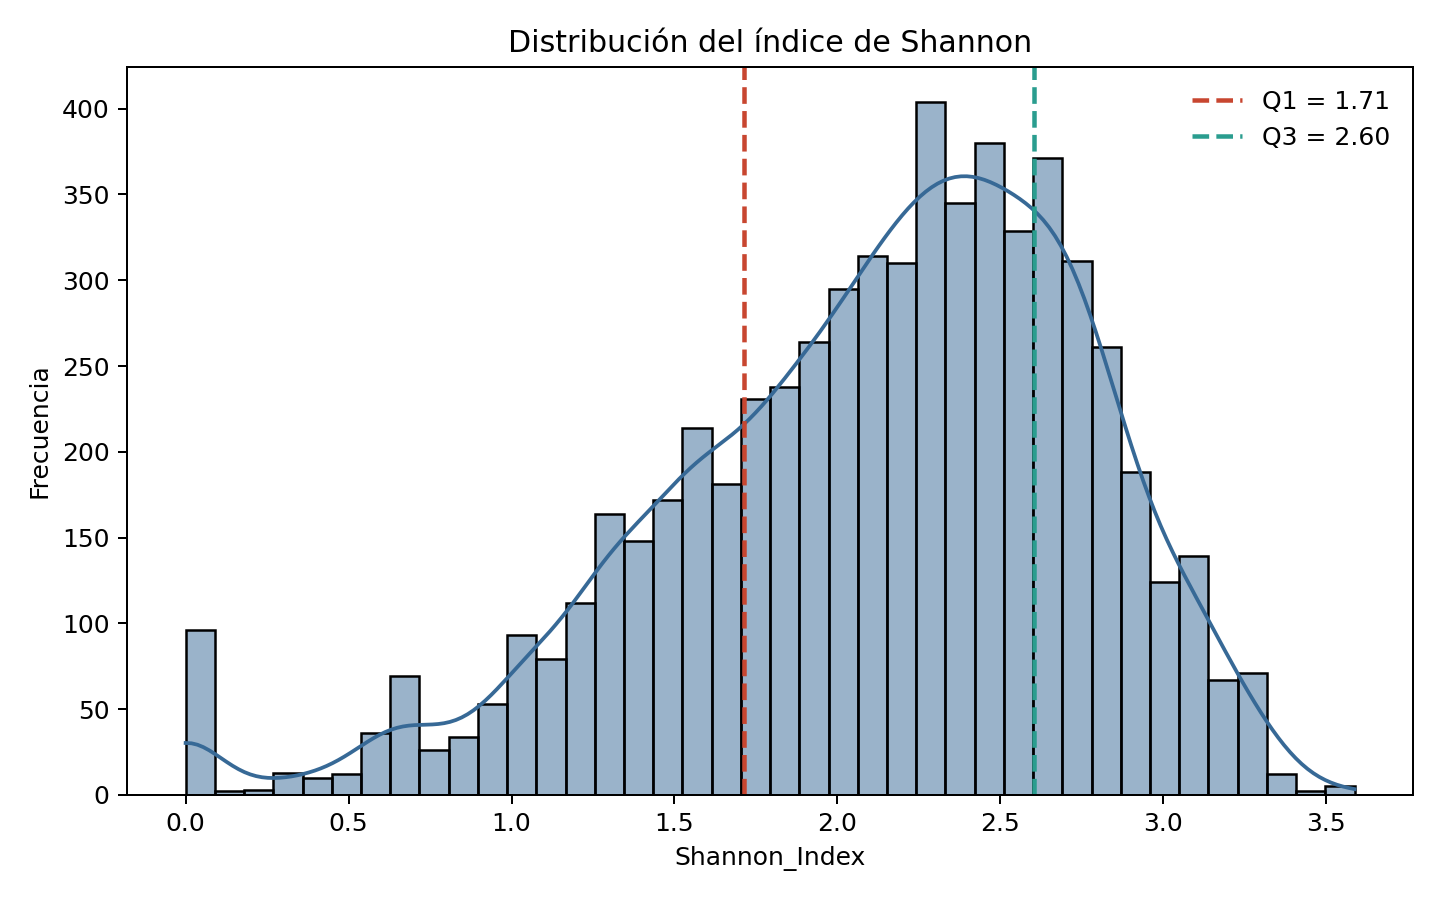

In [3]:
# Graficar distribución de Shannon
eda.plot_shannon_distribution(df)
from IPython.display import Image
Image(filename='Figures/EDA/01_shannon_distribution.png')

## 4. Distribuciones de las Variables Ambientales
Analizamos los histogramas de las variables ambientales en sus escalas físicas originales. 
Observamos:
- Fuertes asimetrías en $PM_{2.5}$ y $PM_{10}$, típicas de distribuciones log-normales de contaminantes en áreas urbanas.
- Una distribución bimodal en la Humedad Relativa y la Radiación Solar, explicada por el contraste drástico entre las horas diurnas y nocturnas.
- La Lluvia es tratada como una variable cualitativa/bimodal (0 = Sin Lluvia, 1 = Con Lluvia) debido a que la gran mayoría de observaciones registran precipitación cero, lo que imposibilita un tratamiento continuo tradicional.

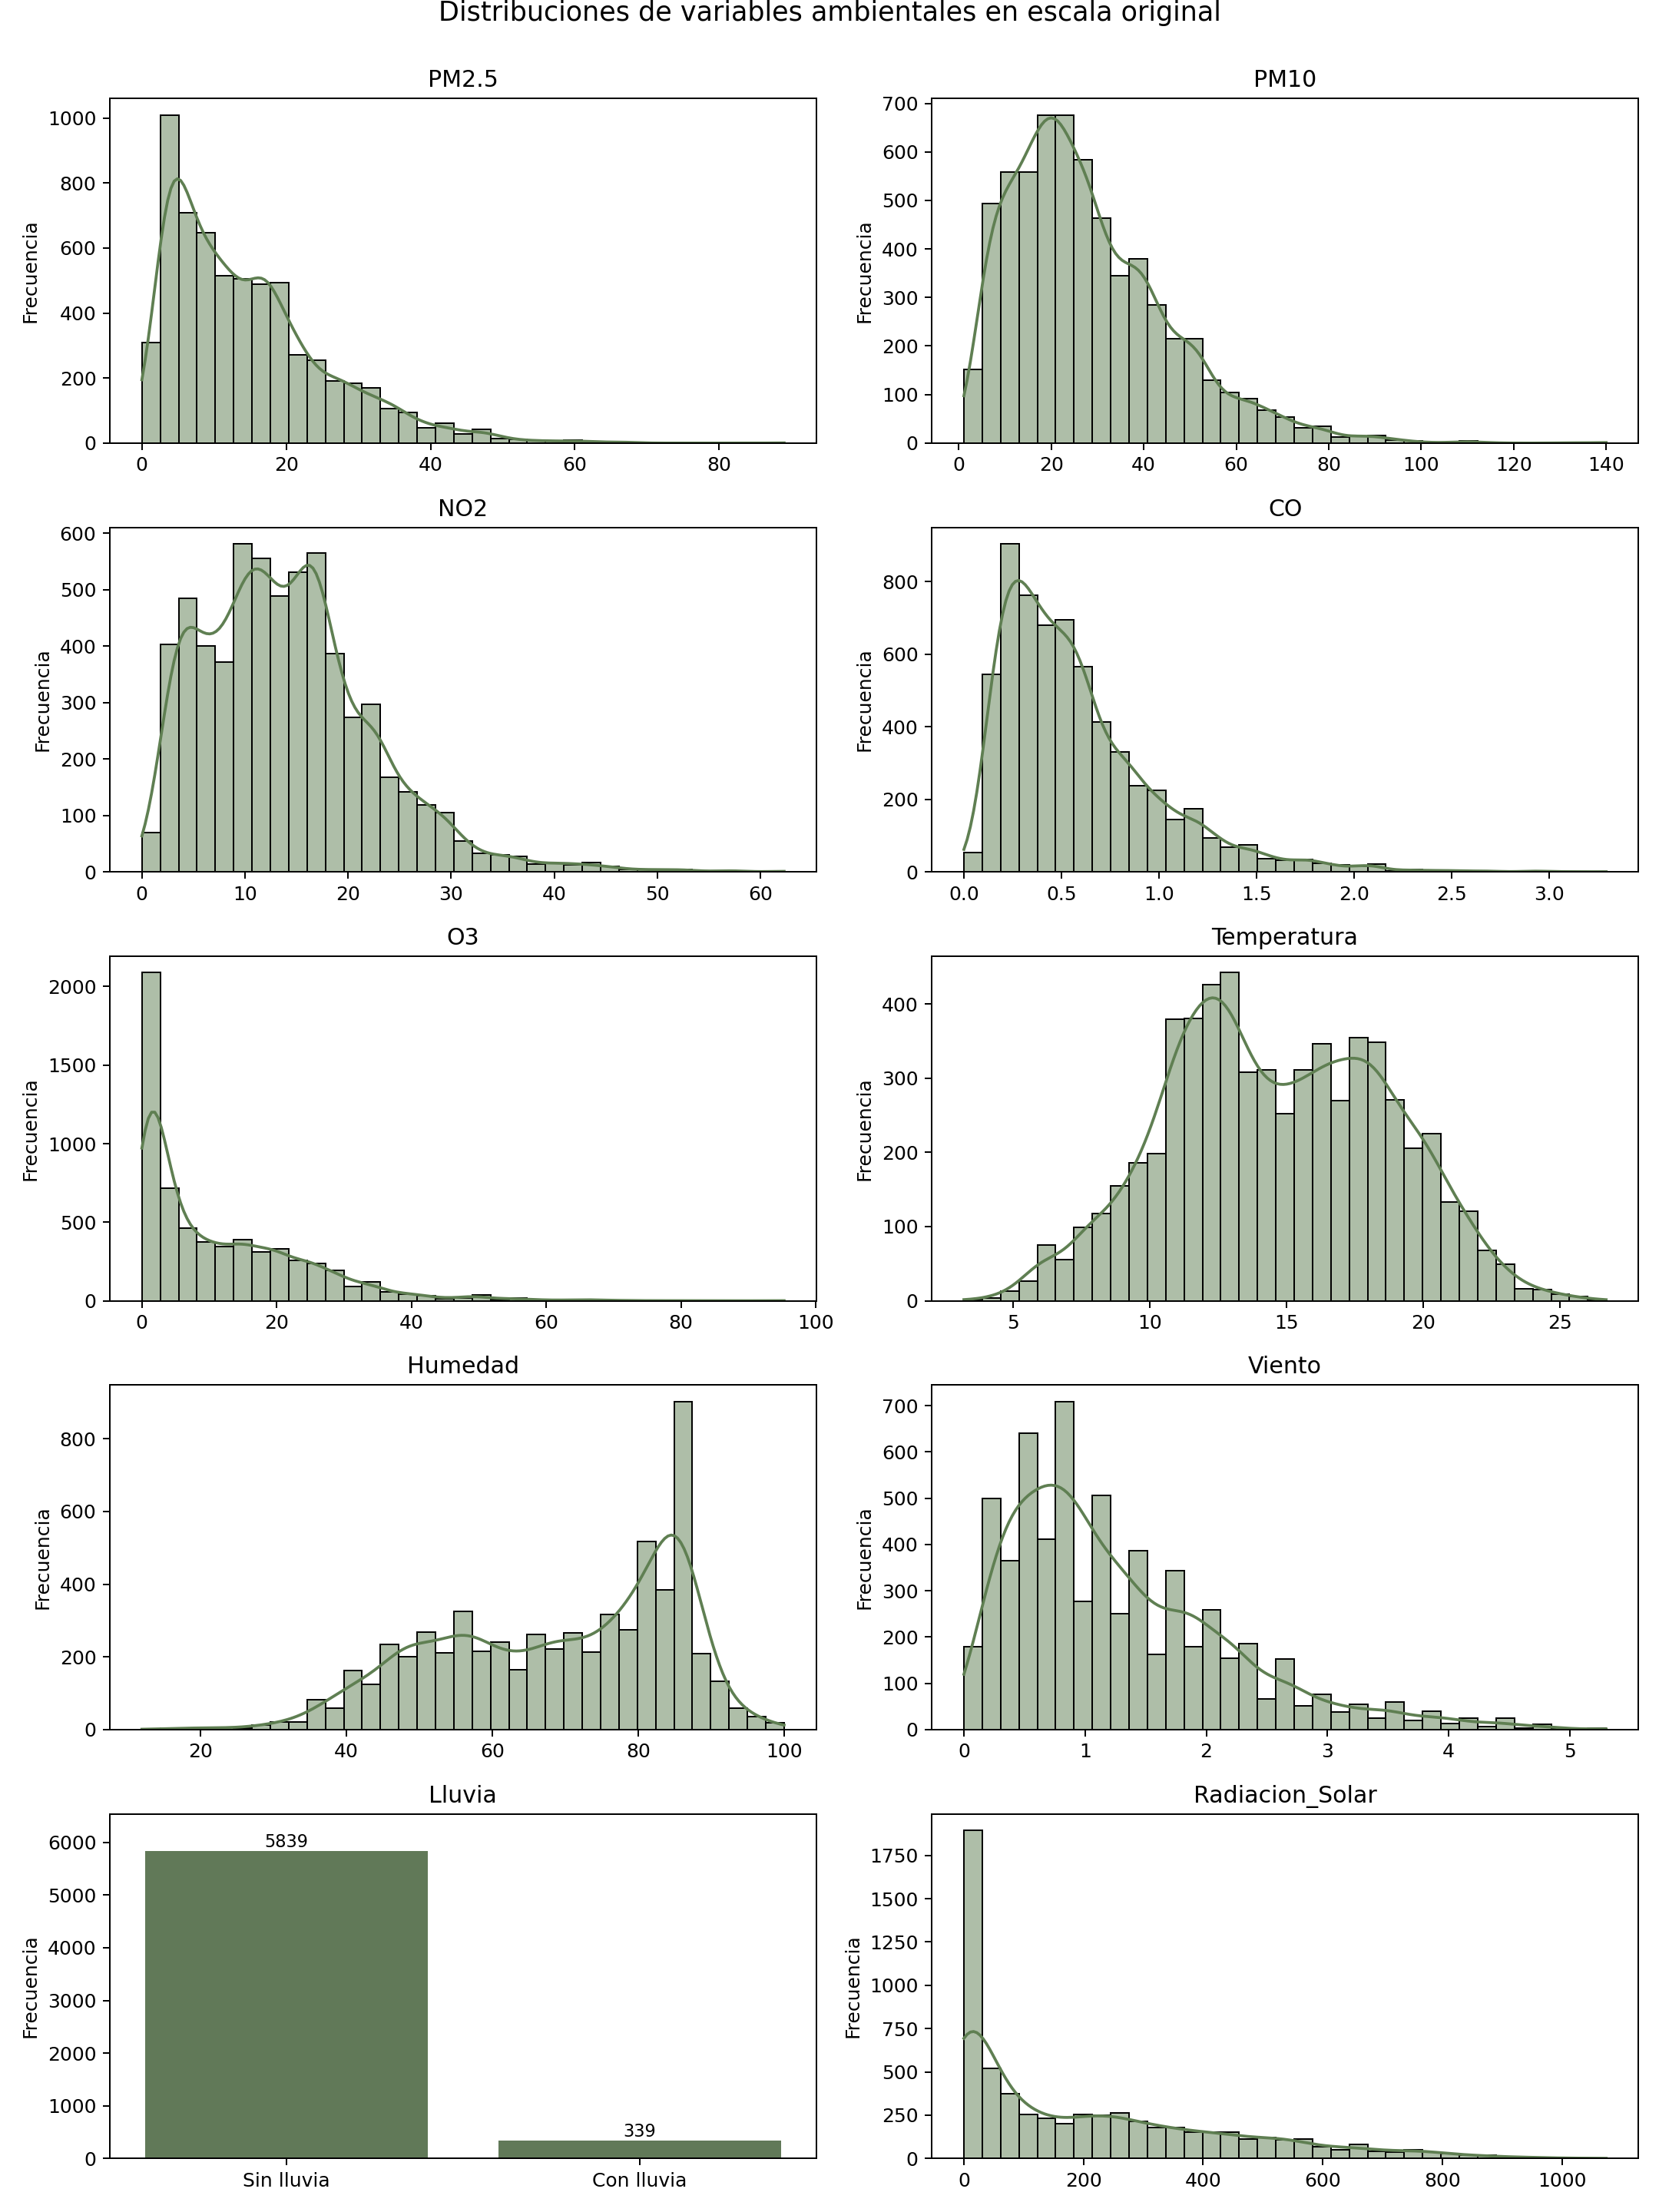

In [4]:
# Graficar histogramas de variables ambientales
eda.plot_environment_distributions(df)
Image(filename='Figures/EDA/02_environment_distributions_original.png')

## 5. Análisis de Correlación Bivariada
Para explorar las asociaciones lineales, calculamos y visualizamos la matriz de correlación de Pearson entre las variables continuas.
Destacan colinealidades físicas e instrumentales esperadas:
1. Alta correlación positiva entre $PM_{2.5}$ y $PM_{10}$ ($r \approx 0.8$), dado que la fracción fina es parte de la fracción gruesa.
2. Fuerte correlación negativa entre Temperatura e Humedad Relativa ($r \approx -0.7$), gobernada por la física de la presión de vapor de saturación.
3. Correlaciones débiles pero significativas de los contaminantes y el clima con el Índice de Shannon.

=== CORRELACIONES MÁS FUERTES CON EL ÍNDICE DE SHANNON ===


,pearson_with_shannon
Riqueza_Especies,0.846050
Temperatura,-0.350363
Humedad,0.318239
O3,-0.296940
Viento,-0.276028
Radiacion_Solar,-0.272861
NO2,0.087254
CO,0.086324


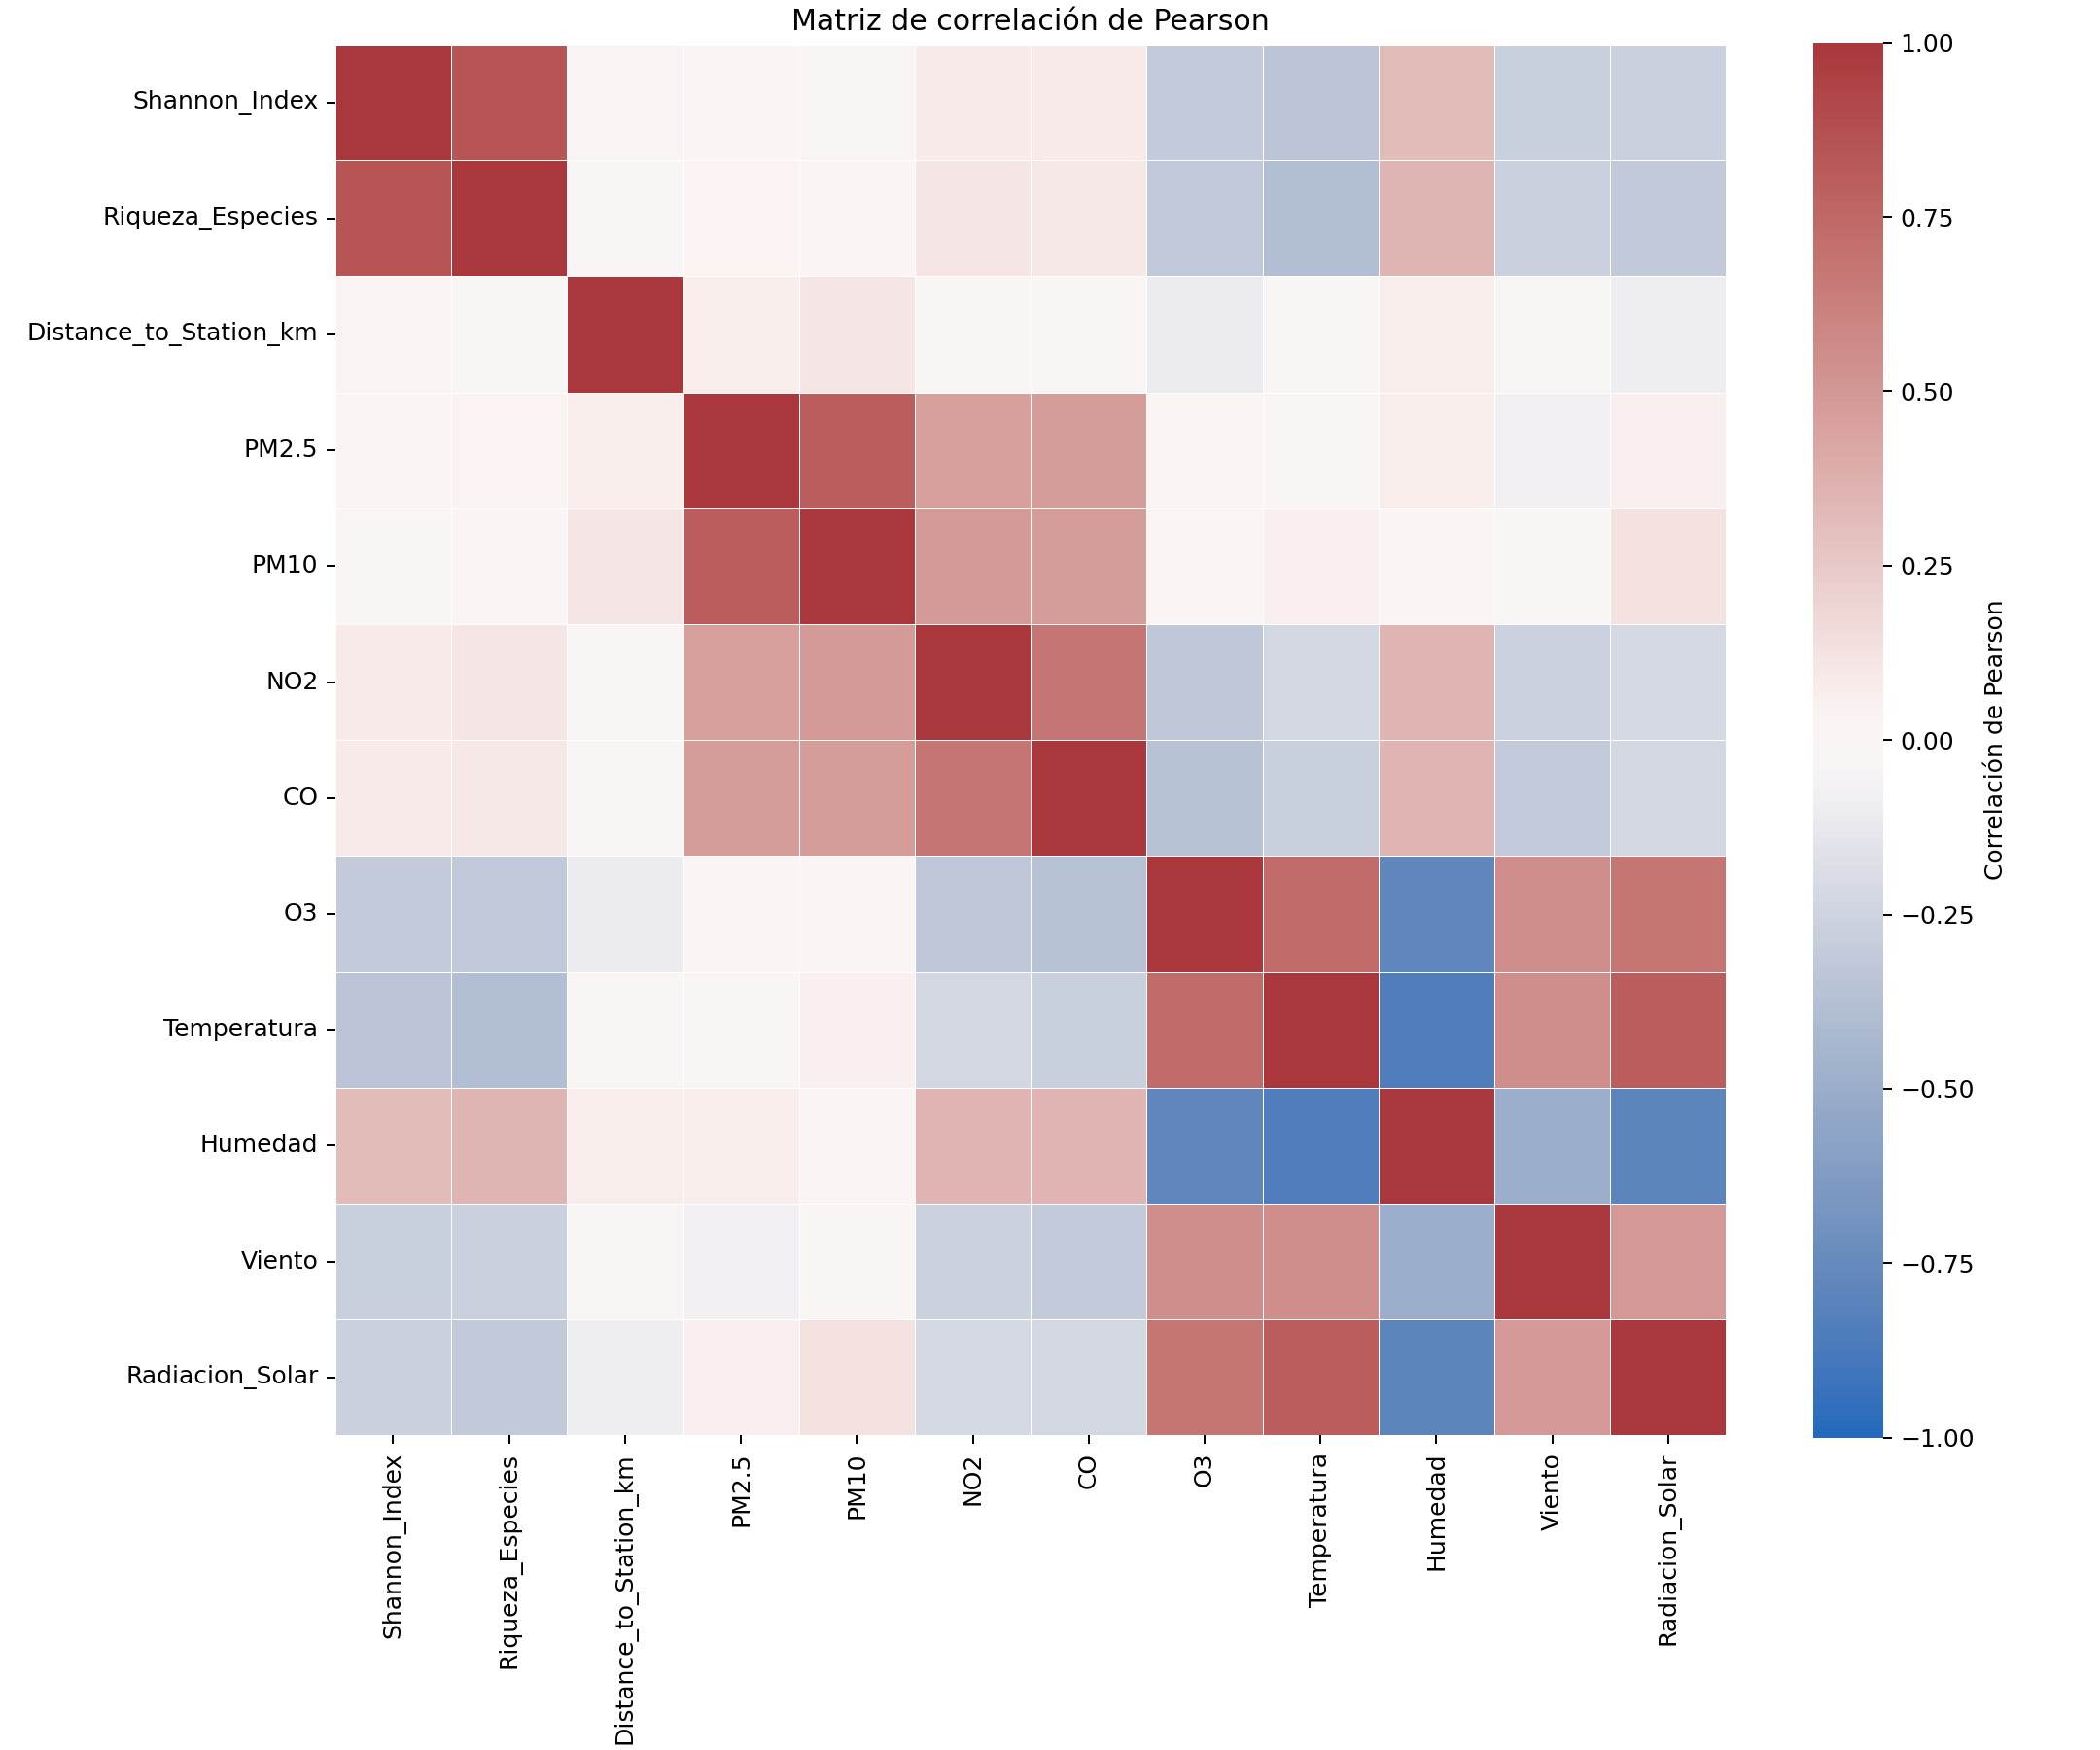

In [5]:
pearson, spearman = eda.save_correlations(df)
eda.plot_correlation_heatmap(pearson)
print("=== CORRELACIONES MÁS FUERTES CON EL ÍNDICE DE SHANNON ===")
top_corr = eda.save_top_correlations(pearson)
display.display(top_corr.head(8))
Image(filename='Figures/EDA/03_pearson_correlation_heatmap.png')

## 6. Relaciones No Lineales con el Índice de Shannon
Evaluamos la relación individual de las principales variables ambientales con el Índice de Shannon mediante diagramas de dispersión con ajustes suavizados **LOWESS** (*Locally Weighted Scatterplot Smoothing*).

El ajuste LOWESS nos permite capturar tendencias no lineales y cambios de curvatura sin imponer una forma funcional a priori (como una recta o parábola), lo cual es crucial para identificar efectos de umbral ecológico.

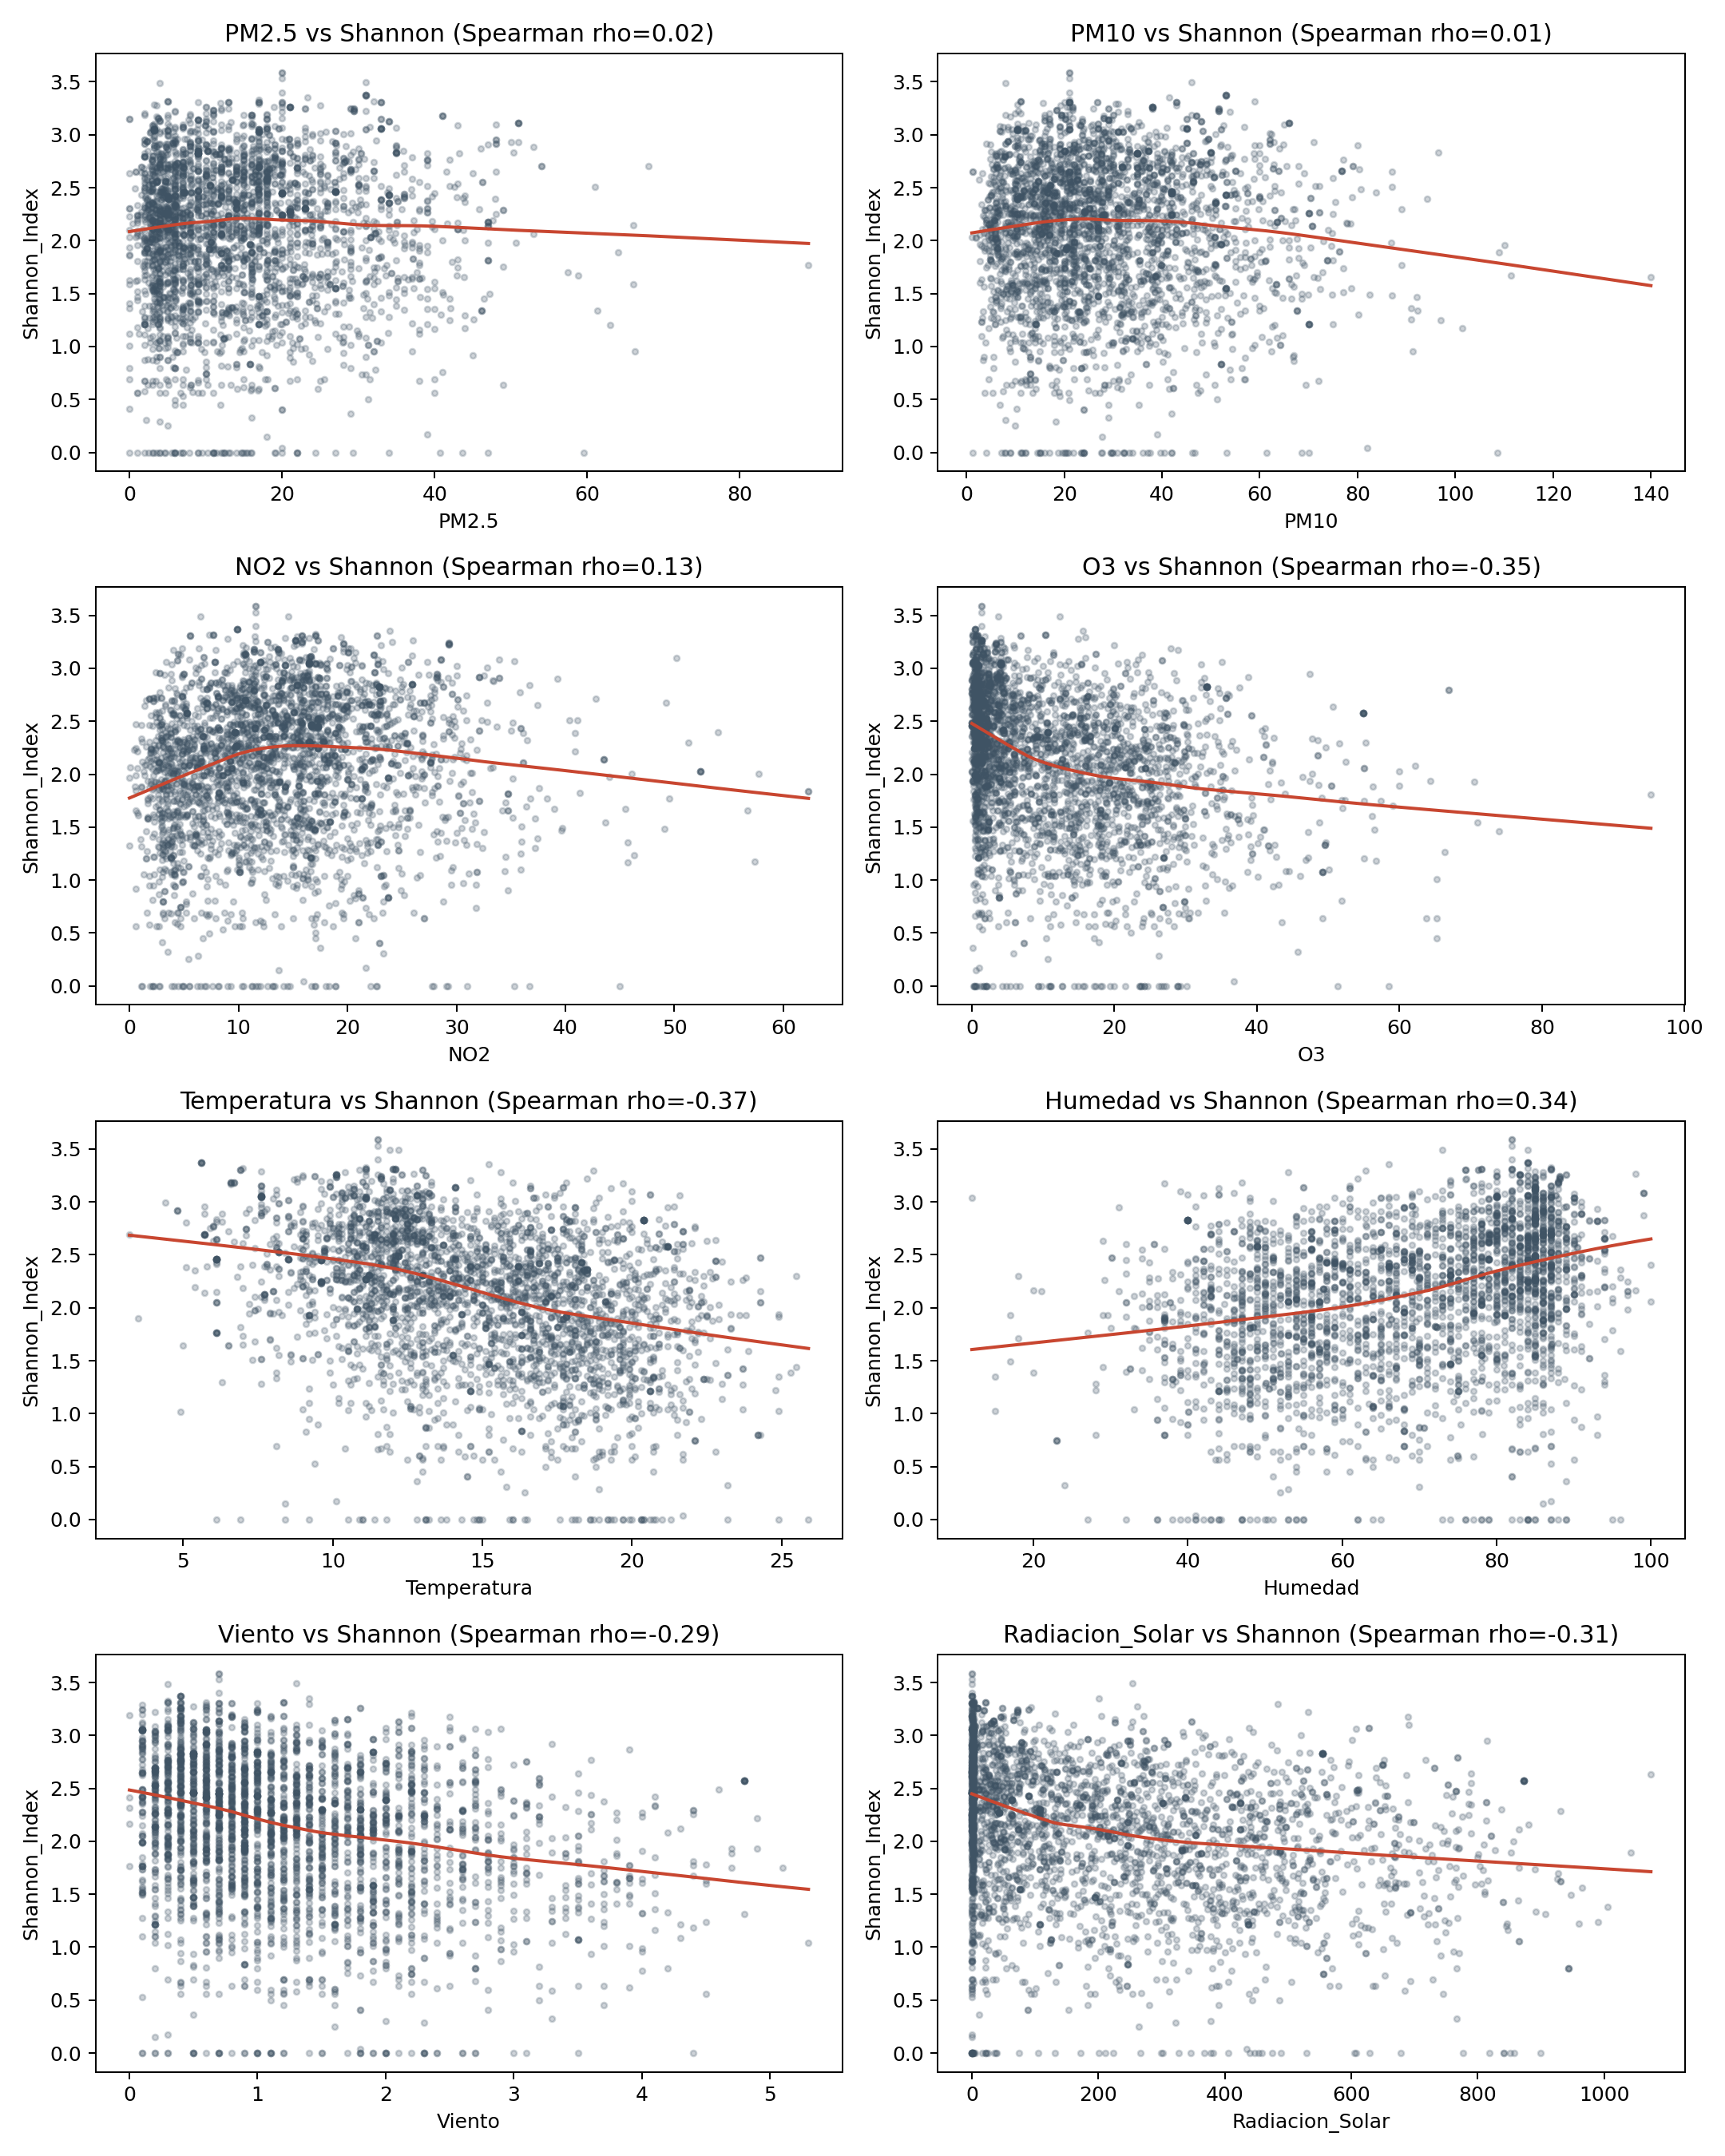

In [6]:
eda.plot_shannon_scatter_grid(df)
Image(filename='Figures/EDA/04_shannon_vs_environment_scatter.png')

## 7. Comparación del Perfil Ambiental en Extremos de Diversidad (Q1 vs Q3)
Para contrastar las condiciones ambientales asociadas a la biodiversidad, dividimos los datos en observaciones con Baja Diversidad ($H' \le Q1$) y Alta Diversidad ($H' \ge Q3$). 

Para hacer las variables comparables e independientes de sus unidades físicas, graficamos sus valores estandarizados ($Z$-scores). Esto permite ver inmediatamente qué variables ambientales se encuentran por encima o por debajo de su media histórica en cada grupo de diversidad.

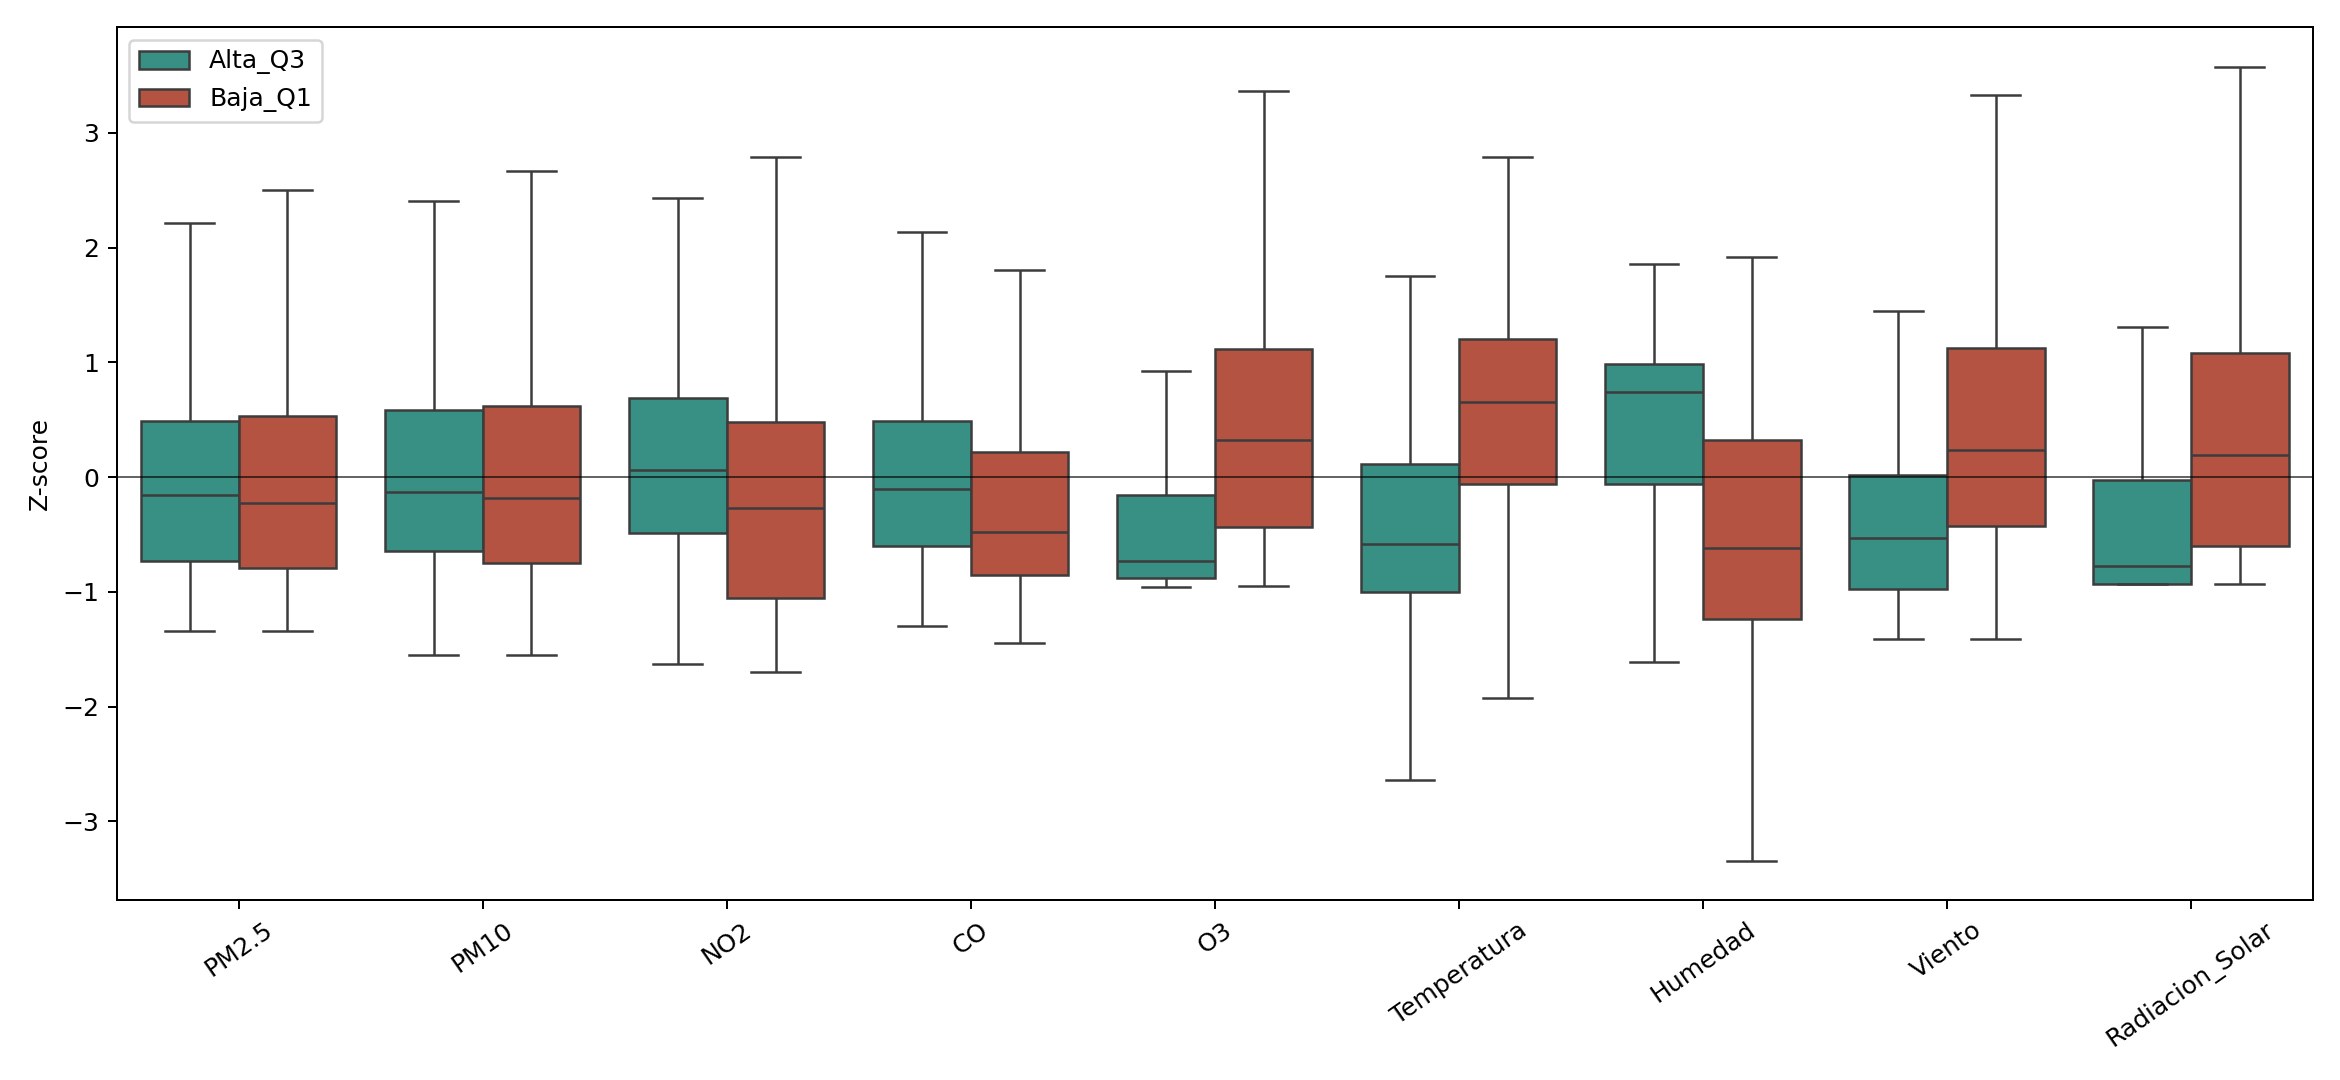

In [7]:
eda.plot_q1_q3_boxplots(df)
Image(filename='Figures/EDA/05_q1_q3_environment_boxplots_z.png')

## Conclusiones del EDA
1. **Heterocedasticidad y Asimetría:** La distribución de los contaminantes y la presencia de asimetrías severas sugieren la conveniencia de usar métodos robustos en la regresión (como errores robustos HC3) y transformaciones o estandarizaciones antes de aplicar métodos multivariables paramétricos.
2. **Multicolinealidad:** Existe una correlación intrínseca muy fuerte en parejas de variables (como Temperatura-Humedad y PM2.5-PM10), lo que podría inflar la varianza en modelos de regresión lineal. Esto justifica hacer análisis de sensibilidad y reducción de dimensiones.
3. **Perfiles Diferenciados:** Se observa preliminarmente que las áreas con Alta Diversidad (Q3) tienden a presentar menores niveles de material particulado y mayor estabilidad térmica, hipótesis que probaremos formalmente en los siguientes módulos.